In [118]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import numpy as np

load_dotenv()
url = os.getenv("DB_URL")

engine = create_engine(url)

In [103]:
import pandas as pd
orders_df = pd.read_sql_table("orders", engine)
orders_df.head(1)

,id,ticker,class_code,timestamp,side,volume,price,quantity
0,1,SR330CD6A,OPTSPOT,2026-03-23 15:59:24+00:00,BUY,1,0,1


In [104]:
orders_df['timestamp'] = pd.to_datetime(orders_df['timestamp'])
orders_df.set_index('timestamp', inplace=True)
orders_df.sort_index(inplace=True)
orders_df['strike'] = orders_df['ticker'].astype(str).str[2:5]

orders_df.head(1)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-03-23 15:59:24+00:00,1,SR330CD6A,OPTSPOT,BUY,1,0,1,330


In [205]:
large_buy_orders = orders_df[orders_df['side'] == "BUY"].sort_values(by='volume', ascending=False).head(500)
large_buy_orders

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310
2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340
2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310
2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310
2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320
...,...,...,...,...,...,...,...,...
2026-04-29 16:02:30+00:00,9345,SR320CQ6B,OPTSPOT,BUY,6585,8,816,320
2026-04-20 10:29:41+00:00,6516,SR320CD6E,OPTSPOT,BUY,6570,6,1000,320
2026-05-06 07:01:55+00:00,10772,SR290CE6A,OPTSPOT,BUY,6566,30,212,290


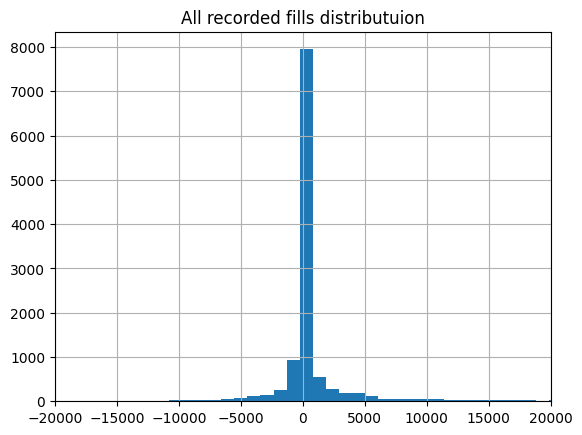

count     11582.000000
mean        458.266966
std        5172.764186
min     -270000.000000
25%         -45.000000
50%          11.000000
75%         240.000000
max      153143.000000
Name: volume, dtype: float64

In [191]:
from matplotlib import pyplot as plt 
hist_df = orders_df.copy()
hist_df.loc[hist_df['side'] == "SELL", 'volume'] *= -1

plt.hist(hist_df['volume'], bins=400)
plt.xlim(-20000, 20000)
plt.grid()
plt.title("All recorded fills distributuion")
plt.show()

hist_df['volume'].describe()

In [107]:
engine = create_engine(url)

orderbooks_df = pd.read_sql("orderbooks", engine)
orderbooks_df.head(1)

,id,ticker,class_code,timestamp,bids,asks,bid_volume,ask_volume
0,959197,SR320CE6A,OPTSPOT,2026-05-04 15:18:06+00:00,"[{'price': 1.33, 'quantity': 800}, {'price': 1...","[{'price': 1.68, 'quantity': 4000}, {'price': ...",136517,11968


In [192]:
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.sort_index(inplace=True)
orderbooks_df.head(1)

KeyError: 'timestamp'

In [193]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['mid'] = (orderbooks_df['best_ask'] + orderbooks_df['best_bid'])/2

orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume,best_bid,best_ask,mid
timestamp,,,,,,,,,,
2026-03-23 15:39:07+00:00,32065,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1,NaN,0.54,NaN


In [194]:
large_buy_orders['ts_adj'] = large_buy_orders.index + pd.Timedelta(microseconds=1)
df = pd.merge_asof(
    large_buy_orders.reset_index().sort_values('ts_adj'), 
    orderbooks_df[['ticker', 'best_bid', 'best_ask', 'mid']].reset_index(),
    left_on='ts_adj', 
    right_on = 'timestamp',
    by='ticker',
    direction='forward')

df.sort_values("volume", ascending=False).head()

,timestamp_x,id,ticker,class_code,side,volume,price,quantity,strike,ts_adj,timestamp_y,best_bid,best_ask,mid
108,2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310,2026-04-01 10:56:46.000001+00:00,2026-04-01 10:58:55+00:00,8.19,8.50,8.345
478,2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340,2026-05-06 13:48:07.000001+00:00,2026-05-06 13:48:12+00:00,16.25,17.99,17.120
10,2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310,2026-03-25 11:46:13.000001+00:00,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
4,2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310,2026-03-25 06:19:33.000001+00:00,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
389,2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320,2026-04-24 19:06:47.000001+00:00,2026-04-24 19:06:48+00:00,8.20,8.78,8.490


In [195]:
df = df[['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'timestamp_y', 'best_bid', 'best_ask', 'mid']]
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid
0,2026-03-24 07:52:22+00:00,SR300CD6,14324,20,300,2026-03-24 07:53:18+00:00,20.16,20.65,20.405
1,2026-03-24 07:53:58+00:00,SR310CD6,9888,12,310,2026-03-24 07:54:00+00:00,11.15,12.24,11.695
2,2026-03-24 08:54:54+00:00,SR310CD6,12360,12,310,2026-03-24 09:04:10+00:00,11.60,12.36,11.980
3,2026-03-24 09:26:50+00:00,SR300CD6A,14560,18,300,2026-03-24 09:26:53+00:00,17.98,18.62,18.300
4,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810


In [216]:
horizons = [1, 2, 3, 4, 5, 30, 60, 120, 480, 720, 1440, 4320, 10080] #minues
print(horizons)
for h in horizons:
    df['time_adj'] = df['timestamp_y'] + pd.Timedelta(minutes=h)
    merged = pd.merge_asof(
        df.sort_values('time_adj'),
        orderbooks_df.reset_index(),
        left_on = 'time_adj',
        right_on = 'timestamp',
        direction = 'nearest',
        tolerance = pd.Timedelta(minutes = h/2),
        by = 'ticker'
    ).sort_index() 
    df[f'best_ask_{h}'] = merged['best_ask_y']
    df[f'best_bid_{h}'] = merged['best_bid_y']
    df[f'mid_{h}'] = merged['mid_y']
    
df.head()

[1, 2, 3, 4, 5, 30, 60, 120, 480, 720, 1440, 4320, 10080]


,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid,time_adj,...,mid_price_return_4775,mid_price_return_5305,mid_price_return_5836,mid_price_return_6366,mid_price_return_6897,mid_price_return_7427,mid_price_return_7958,mid_price_return_8488,mid_price_return_9019,mid_price_return_9549
0,2026-03-24 07:52:22+00:00,SR300CD6,14324,20,300,2026-03-24 07:53:18+00:00,20.16,20.65,20.405,2026-03-31 07:53:18+00:00,...,-0.176427,-0.176182,-0.176182,-0.176182,-0.105121,-0.105121,-0.105121,-0.105121,-0.215143,-0.174712
1,2026-03-24 07:53:58+00:00,SR310CD6,9888,12,310,2026-03-24 07:54:00+00:00,11.15,12.24,11.695,2026-03-31 07:54:00+00:00,...,-0.277469,NaN,NaN,NaN,-0.182557,-0.182557,-0.182557,-0.182557,-0.277897,-0.240701
2,2026-03-24 08:54:54+00:00,SR310CD6,12360,12,310,2026-03-24 09:04:10+00:00,11.60,12.36,11.980,2026-03-31 09:04:10+00:00,...,-0.270451,NaN,NaN,NaN,-0.202003,-0.202003,-0.202003,-0.225376,-0.270868,-0.258765
3,2026-03-24 09:26:50+00:00,SR300CD6A,14560,18,300,2026-03-24 09:26:53+00:00,17.98,18.62,18.300,2026-03-31 09:26:53+00:00,...,-0.179235,-0.208743,-0.208743,-0.208743,-0.125137,-0.125137,-0.125137,-0.131148,-0.180055,-0.204918
4,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810,2026-04-01 06:19:34+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [217]:
for h in horizons:
    df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']

In [218]:
filtered_df = df.loc[df['strike'].astype(int) > 340]

snr_not_filtered = []
snr_filtered = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    filtered_returns = df.loc[df['strike'].astype(int) > 330][f'mid_price_return_{h}'].dropna()

    print(f"h = {h}, count = {len(returns)}")
    mean = returns.mean()
    std = returns.std()
    snr_not_filtered.append(mean/std)

    mean = filtered_returns.mean()
    std = filtered_returns.std()
    snr_filtered.append(mean/std)

h = 1, count = 253
h = 2, count = 299
h = 3, count = 334
h = 4, count = 351
h = 5, count = 366
h = 30, count = 459
h = 60, count = 480
h = 120, count = 476
h = 480, count = 380
h = 720, count = 319
h = 1440, count = 387
h = 4320, count = 281
h = 10080, count = 339


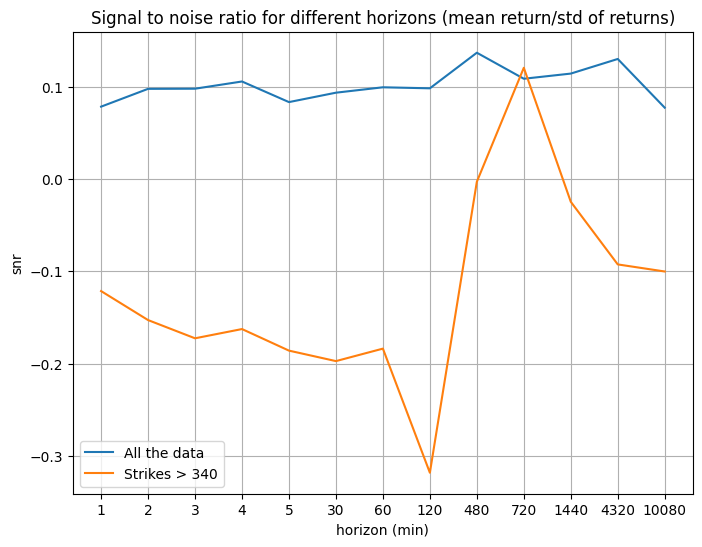

In [219]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), snr_not_filtered, label="All the data")
plt.plot(range(len(horizons)), snr_filtered, label="Strikes > 340")
plt.xticks(range(len(horizons)), horizons)
plt.grid()
plt.title("Signal to noise ratio for different horizons (mean return/std of returns)")
plt.xlabel("horizon (min)")
plt.ylabel("snr")
plt.legend()
plt.show()

In [220]:
stats = pd.DataFrame({
    'mean': [df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std': [df[f'mid_price_return_{h}'].std() for h in horizons],
    'count': [df[f'mid_price_return_{h}'].notna().sum() for h in horizons],
    'mean_otm': [filtered_df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std_otm': [filtered_df[f'mid_price_return_{h}'].std() for h in horizons],
    'count_otm': [filtered_df[f'mid_price_return_{h}'].notna().sum() for h in horizons]
}, index=horizons)
stats

,mean,std,count,mean_otm,std_otm,count_otm
1,0.072849,0.928699,253,0.004836,0.006456,7
2,0.093060,0.952180,299,0.004426,0.005055,8
3,0.088455,0.903559,334,0.001865,0.003630,8
4,0.093487,0.884384,351,-0.000509,0.007637,8
5,0.065860,0.789809,366,0.000337,0.008066,8
30,0.096788,1.034337,459,-0.068392,0.207620,10
60,0.105602,1.062097,480,-0.071301,0.208298,10
120,0.125611,1.277639,476,-0.069559,0.213877,10
480,0.284981,2.081993,380,-0.060499,0.235953,9
720,0.999315,9.195075,319,-0.073015,0.270476,7


In [221]:
from scipy import stats

rows = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    t_stat, p_value = stats.ttest_1samp(returns, popmean=0)

    rows.append({
        'horizon': h,
        't_stat': t_stat,
        'p_value': p_value
    })

t_test_res = pd.DataFrame(rows)
t_test_res

,horizon,t_stat,p_value
0,1,1.247703,0.213298
1,2,1.689977,0.092078
2,3,1.789110,0.074506
3,4,1.980457,0.048435
4,5,1.595283,0.111514
5,30,2.004774,0.045575
6,60,2.178352,0.029867
7,120,2.144969,0.032462
8,480,2.668261,0.007952
9,720,1.941075,0.053132


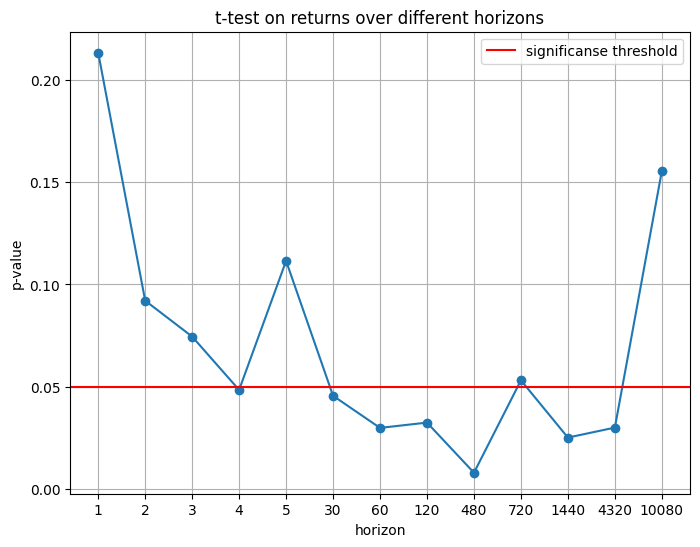

In [222]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), t_test_res['p_value'], marker="o")
plt.xticks(range(len(horizons)), horizons)
plt.xticks()
plt.grid()
plt.xlabel("horizon")
plt.ylabel("p-value")
plt.axhline(0.05, color='red', label="significanse threshold")
plt.title("t-test on returns over different horizons")
plt.legend()
plt.show()

In [244]:
df.columns[0:20]

cols = ['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'best_ask'] + [f'best_bid_{h}' for h in horizons] 
backtest_df = df[cols]

for h in horizons:
    ask = backtest_df[f'best_ask']
    bid = backtest_df[f'best_bid_{h}']
    backtest_df[f'bid_ask_return_{h}'] = (bid - ask)/ask
backtest_df.head(1)

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_1,best_bid_2,best_bid_3,best_bid_4,...,bid_ask_return_4,bid_ask_return_5,bid_ask_return_30,bid_ask_return_60,bid_ask_return_120,bid_ask_return_480,bid_ask_return_720,bid_ask_return_1440,bid_ask_return_4320,bid_ask_return_10080
0,2026-03-24 07:52:22+00:00,SR300CD6,14324,20,300,20.65,19.92,20.1,NaN,NaN,...,NaN,-0.026634,-0.018402,-0.018402,-0.015496,-0.435351,-0.013075,0.012107,-0.094431,-0.231961


In [247]:
av_returns = []
for h in horizons:
    av_returns.append(backtest_df[f'bid_ask_return_{h}'].mean())

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_1,best_bid_2,best_bid_3,best_bid_4,...,average_return_4,average_return_5,average_return_30,average_return_60,average_return_120,average_return_480,average_return_720,average_return_1440,average_return_4320,average_return_10080
0,2026-03-24 07:52:22+00:00,SR300CD6,14324,20,300,20.65,19.92,20.10,NaN,NaN,...,0.005003,-0.012952,0.008696,0.004571,0.023723,-0.115415,-0.338735,0.008558,-0.250531,-0.077583
1,2026-03-24 07:53:58+00:00,SR310CD6,9888,12,310,12.24,11.35,11.35,NaN,NaN,...,0.005003,-0.012952,0.008696,0.004571,0.023723,-0.115415,-0.338735,0.008558,-0.250531,-0.077583
2,2026-03-24 08:54:54+00:00,SR310CD6,12360,12,310,12.36,NaN,NaN,NaN,NaN,...,0.005003,-0.012952,0.008696,0.004571,0.023723,-0.115415,-0.338735,0.008558,-0.250531,-0.077583
3,2026-03-24 09:26:50+00:00,SR300CD6A,14560,18,300,18.62,NaN,NaN,NaN,NaN,...,0.005003,-0.012952,0.008696,0.004571,0.023723,-0.115415,-0.338735,0.008558,-0.250531,-0.077583
4,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,9.31,8.31,NaN,8.31,8.31,...,0.005003,-0.012952,0.008696,0.004571,0.023723,-0.115415,-0.338735,0.008558,-0.250531,-0.077583
